NDVI moyen: 0.6311014296122184
NDVI min: -0.7564575706626383
NDVI max: 1.0


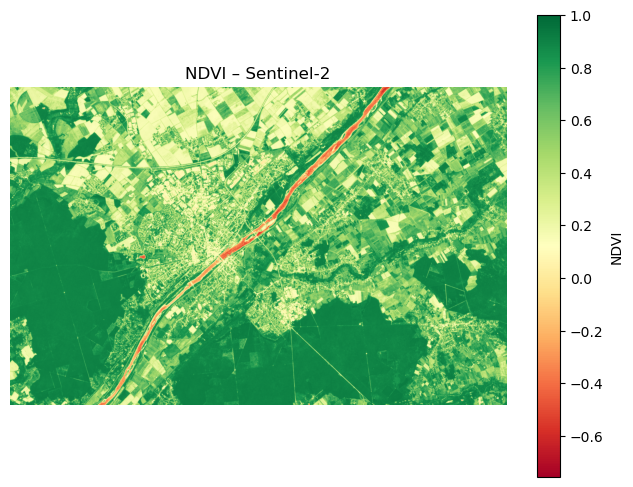

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#Chemins vers les bandes Sentiel-2 ( B04, B08 )
red_path = Path("C:/Users/Enzo/Folium/AutoGIS/Browser_images/2025-09-19-00_00_2025-09-19-23_59_Sentinel-2_L2A_B04_(Raw).tiff")
nir_path = Path("C:/Users/Enzo/Folium/AutoGIS/Browser_images/2025-09-19-00_00_2025-09-19-23_59_Sentinel-2_L2A_B08_(Raw).tiff")

# Chargement et normalisation des bandes d'images satellites
def load_band(path:str):
    with rasterio.open(path) as src:
        band = src.read(1).astype(float)
        profile = src.profile
    return band, profile

#Calcule le NDVI et clip les valeurs entre -1 et 1
def calculate_ndvi(nir:int, red:int):
    nir /= 10000
    red /= 10000
    ndvi = (nir - red) / (nir + red)
    ndvi[np.isinf(ndvi)] = np.nan
    return np.clip(ndvi, -1, 1)
    
# Légende / colormap
def plot_ndvi(ndvi, title="NDVI – Sentinel-2"):
    plt.figure(figsize=(8, 6))
    plt.imshow(ndvi, cmap="RdYlGn")
    plt.colorbar(label="NDVI")
    plt.title(title)
    plt.axis("off")
    plt.show()

# Statistiques
def statistics(ndvi):
    print("NDVI moyen:", np.nanmean(ndvi))
    print("NDVI min:", np.nanmin(ndvi))
    print("NDVI max:", np.nanmax(ndvi))


#Lecture des bandes
red, profile = load_band(red_path)
nir, _ = load_band(nir_path)

#Calcul du NDVI
ndvi = calculate_ndvi(nir, red)

#Statistiques
statistics(ndvi)

#Visualisation
plot_ndvi(ndvi)